<a href="https://colab.research.google.com/github/Sebas-Atehortua/Integracion-de-Datos-y-Prospectiva/blob/main/Integraci%C3%B3n_DB_EPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integración de Datos y Análisis de Credibilidad - Caso Entidades Promotoras de Salud (EPS)**

El siguiente modelo tiene como objetivo integrar la información de pacientes de la sucursal de Sabaneta que está próxima a cerrar hacia las demás sucursales de la red prestadora de salud. Se trata de garantizar una reubicación estadísticamente consistente, que mitigue el impacto operativo y mantenga estable el perfil clínico de las sucursales que recibirán a estos pacientes.

Dado que la información de los pacientes varía entre las sucursales y la estructura poblacional de cada clínica es distinta, se emplea la **Teoría de la Credibilidad** para determinar el grado de afinidad o compatibilidad de la sucursal de Sabaneta con las demás sedes. Posteriormente, se utilizan métodos aleatorios (Valor de Pertenencia y Aceptación/Rechazo) para la asignación óptima de cada paciente.

Para seleccionar la variable de interés, se tuvo en cuenta las variables que logran replicarse en la base de datos:

*   Índice de Masa Corporal (BMI) como unidad física y fundamental para caracterizar a los pacientes propensos a sufrir de diabetes.
*   Función de Pedrigrí de Diabetes (DiabetesPedigreeFunction) como dato que refleja la herencia genética

Con ambas variables se podría construir un modelo apropiado, sin embargo, a diferencia de la función de pedrigrí, el BMI suele seguir una distribución de campana en la que la mayoría de los pacientes se sitúan en el centro, facilitando una media hipotética estable para la construcción de los métodos aleatorios que se van a emplear.





0. Se cargan las librerías de trabajo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm

# Configuración de estilo
sns.set_theme(style="whitegrid")

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Se montan los archivos de trabajo

**Nota**: Dado que el archivo tiene múltiples hojas y algunas difieren en columnas, cargaremos todas las hojas y extraeremos únicamente la variable de interés (BMI) para evitar conflictos.

In [3]:
# Cargar base de datos unificada con múltiples hojas
db = '/content/drive/MyDrive/Integración de Datos/Parcial #1/3. Parcial - medical_attention_data.xlsx'
hojas = ['Bello', 'Envigado', 'Medellín', 'Itagui', 'Sabaneta', 'Caldas']
datos_sucursales = {}

var_ref = 'BMI'

# Extracción iterativa de la variable de referencia por sucursal

for hoja in hojas:
    df = pd.read_excel(db, sheet_name=hoja)
    datos_sucursales[hoja] = df[var_ref].dropna().values

sabaneta_bmi = datos_sucursales['Sabaneta']

2. Se crea la función de caracterización de las variables

In [4]:
def caracterizacion(X, nombre, plot=False):
    print(f"\n===== {nombre} =====")
    media = round(np.mean(X), 2)
    varianza = round(np.var(X), 2)
    desviacion = round(np.std(X), 2)
    asimetria = round(skew(X), 2)
    curtosis = round(kurtosis(X), 2)

    print("Media:", media)
    print("Varianza:", varianza)
    print("Desviación:", desviacion)
    print("Asimetría:", asimetria)
    print("Curtosis:", curtosis)

    if plot:
        plt.figure(figsize=(6,4))
        sns.histplot(X, bins=15, kde=True, color='teal')
        plt.title(f"Distribución de {var_ref} - {nombre}")
        plt.xlabel(var_ref)
        plt.ylabel("Frecuencia de ocurrencia")
        plt.grid(True, alpha=0.3)
        plt.show()

    return media, varianza, desviacion, asimetria, curtosis

2.1. Se caracterizan las variables en medidas de tendencia central


===== Sabaneta =====
Media: 32.99
Varianza: 97.75
Desviación: 9.89
Asimetría: -0.02
Curtosis: -1.15


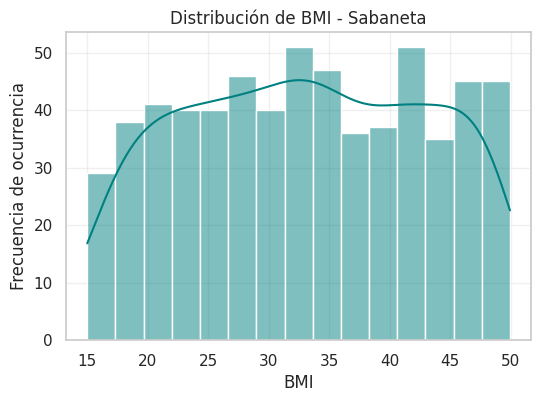

In [5]:
u_sab, var_sab, std_sab, asim_sab, curt_sab = caracterizacion(sabaneta_bmi, "Sabaneta", plot=True)

Como se observa en la salida del modelo, la variable BMI en la sucursal de Sabaneta presenta una media de 32.99, lo que sitúa al paciente promedio en un rango de obesidad grado I. La desviación estándar de 9.89 sugiere una dispersión moderada, permitiendo que el modelo capture una amplia gama de perfiles clínicos.

3. **Se aplica la Teoría de la Credibilidad**

Se calcula el factor de credibiidad para cada una de las sucursales receptoras

In [17]:
# Se configuran pandas para que muestren 4 decimales y no usen la notación científica
pd.options.display.float_format = '{:.1f}'.format

afinidad_resultados = []
ND_sab = len(sabaneta_bmi)

for sucursal, datos in datos_sucursales.items():
    if sucursal == 'Sabaneta':
        continue

    ND_ext = len(datos)
    u_ext = np.mean(datos)
    std_ext = np.std(datos)

    # 1. Media hipotética combinada
    uhat = (ND_sab*u_sab + ND_ext*u_ext) / (ND_sab + ND_ext)

    # 2. EPV (Expected Process Variance)
    EPV = (ND_sab*(std_sab**2) + ND_ext*(std_ext**2)) / (ND_sab + ND_ext)

    # 3. VHM (Variance of Hypothetical means)
    VHM = ((ND_sab*(u_sab**2) + ND_ext*(u_ext**2)) / (ND_sab + ND_ext)) - uhat**2
    if VHM <= 0: VHM = 0.0001 # Ajuste para varianzas casi idénticas

    # 4. Parámetro K
    K = EPV / VHM

    # 5. Factor de credibilidad Z
    Z = ND_sab / (ND_sab + K)

    afinidad_resultados.append({'Sucursal': sucursal, 'Credibilidad_Z': round(Z, 4), 'Parametro_K': round(K, 4)})

df_afinidad = pd.DataFrame(afinidad_resultados).sort_values(by='Credibilidad_Z', ascending=False)
print(df_afinidad)

   Sucursal  Credibilidad_Z  Parametro_K
3    Itagui             0.5        704.5
1  Envigado             0.2       2039.5
2  Medellín             0.0      33598.3
4    Caldas             0.0      77975.9
0     Bello             0.0 1714025673.6


In [16]:
# Verificación manual de medias y desviaciones
print(f"Media Sabaneta: {np.mean(sabaneta_bmi):.2f} | Desviación: {np.std(sabaneta_bmi):.2f}")
print(f"Media Itagui:  {np.mean(datos_sucursales['Itagui']):.2f} | Desviación: {np.std(datos_sucursales['Itagui']):.2f}")
print(f"Media Bello:   {np.mean(datos_sucursales['Bello']):.2f} | Desviación: {np.std(datos_sucursales['Bello']):.2f}")

Media Sabaneta: 32.99 | Desviación: 9.89
Media Itagui:  32.24 | Desviación: 9.96
Media Bello:   32.99 | Desviación: 9.87
